In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df = pd.read_csv("7_real_estate_prices.csv")

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   property_id                 15000 non-null  str    
 1   listing_date                15000 non-null  str    
 2   property_type               15000 non-null  str    
 3   city                        15000 non-null  str    
 4   neighborhood_tier           15000 non-null  str    
 5   zipcode_crime_rate          15000 non-null  float64
 6   school_rating               15000 non-null  int64  
 7   distance_to_downtown_miles  15000 non-null  float64
 8   walk_score                  15000 non-null  int64  
 9   bedrooms                    15000 non-null  int64  
 10  bathrooms                   15000 non-null  float64
 11  square_feet                 14250 non-null  float64
 12  lot_size_sqft               15000 non-null  int64  
 13  stories                     15000 non-null

In [38]:
df.describe()

,zipcode_crime_rate,school_rating,distance_to_downtown_miles,walk_score,bedrooms,bathrooms,square_feet,lot_size_sqft,stories,garage_spaces,year_built,house_age,renovation_year,years_since_renovation,days_on_market,interest_rate,hoa_fees,sale_price
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14250.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,6495.000000,15000.000000,15000.000000,15000.000000,14250.000000,1.500000e+04
mean,2.924115,6.993933,8.067307,54.130133,3.367600,2.393467,2145.772982,7930.426933,1.748400,1.601267,1982.066400,41.933600,2011.538106,28.633667,29.671667,6.503533,87.895368,7.827253e+05
std,2.922573,1.499838,7.818909,19.631552,1.116969,0.772889,532.833151,7697.859543,0.620583,0.911665,24.337798,24.337798,6.953233,23.718430,29.775319,0.804532,133.036807,1.622376e+05
min,0.000000,2.000000,0.500000,10.000000,1.000000,1.000000,248.000000,1000.000000,1.000000,0.000000,1940.000000,1.000000,2000.000000,1.000000,1.000000,3.050000,-109.000000,1.449700e+05
25%,0.870000,6.000000,2.300000,41.000000,3.000000,2.000000,1790.250000,2275.750000,1.000000,1.000000,1961.000000,20.000000,2006.000000,10.000000,8.000000,5.950000,0.000000,6.715468e+05
50%,2.030000,7.000000,5.600000,54.000000,3.000000,2.500000,2145.000000,5527.000000,2.000000,2.000000,1983.000000,41.000000,2012.000000,20.000000,21.000000,6.510000,0.000000,7.799125e+05
75%,4.032500,8.000000,11.100000,68.000000,4.000000,3.000000,2502.000000,10823.250000,2.000000,2.000000,2004.000000,63.000000,2018.000000,45.000000,42.000000,7.040000,196.000000,8.913538e+05
max,31.190000,10.000000,40.000000,100.000000,6.000000,4.000000,4154.000000,50000.000000,3.000000,3.000000,2023.000000,84.000000,2023.000000,84.000000,301.000000,9.740000,673.000000,1.372699e+06


In [39]:
df.isnull().sum()

property_id                      0
listing_date                     0
property_type                    0
city                             0
neighborhood_tier                0
zipcode_crime_rate               0
school_rating                    0
distance_to_downtown_miles       0
walk_score                       0
bedrooms                         0
bathrooms                        0
square_feet                    750
lot_size_sqft                    0
stories                          0
garage_spaces                    0
year_built                       0
house_age                        0
has_basement                     0
has_pool                         0
overall_condition                0
kitchen_quality                  0
hvac_condition                   0
roof_condition                   0
renovation_year               8505
years_since_renovation           0
days_on_market                   0
listing_season                   0
market_trend                     0
interest_rate       

REPLACING NULL VALUES WITH MEDIAN AND ZERO

In [40]:
df["square_feet"] = df["square_feet"].fillna(df["square_feet"].median())
df["hoa_fees"] = df["hoa_fees"].fillna(0)
df["was_renovated"] = df["renovation_year"].notnull().astype(int)

DROPING COLUMNS

In [41]:
df.drop("renovation_year",axis = 1,inplace = True)
df.drop("property_id",axis = 1,inplace = True)

In [42]:
df.isnull().sum()

listing_date                  0
property_type                 0
city                          0
neighborhood_tier             0
zipcode_crime_rate            0
school_rating                 0
distance_to_downtown_miles    0
walk_score                    0
bedrooms                      0
bathrooms                     0
square_feet                   0
lot_size_sqft                 0
stories                       0
garage_spaces                 0
year_built                    0
house_age                     0
has_basement                  0
has_pool                      0
overall_condition             0
kitchen_quality               0
hvac_condition                0
roof_condition                0
years_since_renovation        0
days_on_market                0
listing_season                0
market_trend                  0
interest_rate                 0
has_fireplace                 0
has_patio_deck                0
has_security_system           0
hoa_fees                      0
sale_pri

In [43]:
for col in df.select_dtypes(include="object").columns:
    print(col, df[col].nunique())

listing_date 365
property_type 4
city 5
neighborhood_tier 4
has_basement 2
has_pool 2
overall_condition 4
kitchen_quality 4
hvac_condition 4
roof_condition 4
listing_season 4
market_trend 3
has_fireplace 2
has_patio_deck 2
has_security_system 2
high_value_property 2


C:\Users\SafirudinKM\AppData\Local\Temp\ipykernel_18956\1826314449.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [44]:
df["listing_date"] = pd.to_datetime(df["listing_date"])

C:\Users\SafirudinKM\AppData\Local\Temp\ipykernel_18956\1439737229.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["listing_date"] = pd.to_datetime(df["listing_date"])


In [45]:
df["listing_year"] = df["listing_date"].dt.year
df["listing_month"] = df["listing_date"].dt.month
df["listing_day"] = df["listing_date"].dt.day

In [46]:
df = df.drop("listing_date", axis=1)

CREATING NEW FEATURE CALLED AGE_CATEGORY

In [47]:
df["age_category"] = pd.cut(
    df["house_age"],
    bins=[0, 10, 25, 50, 200],
    labels=["New", "Moderate", "Old", "Very Old"]
)

CREATING NEW FEARURE CALLED TOTAL_ROOMS

In [48]:
df["total_rooms"] = df["bedrooms"] + df["bathrooms"]
df["house_age"] = 2025 - df["year_built"]

PERFORMING ONE HOT ENCODING

In [49]:
df = pd.get_dummies(df,drop_first = True)

In [50]:
df.columns

Index(['zipcode_crime_rate', 'school_rating', 'distance_to_downtown_miles',
       'walk_score', 'bedrooms', 'bathrooms', 'square_feet', 'lot_size_sqft',
       'stories', 'garage_spaces', 'year_built', 'house_age',
       'years_since_renovation', 'days_on_market', 'interest_rate', 'hoa_fees',
       'sale_price', 'was_renovated', 'listing_year', 'listing_month',
       'listing_day', 'total_rooms', 'property_type_Multi-Family',
       'property_type_Single Family', 'property_type_Townhouse', 'city_Austin',
       'city_Denver', 'city_Phoenix', 'city_Seattle',
       'neighborhood_tier_Developing', 'neighborhood_tier_Good',
       'neighborhood_tier_Premium', 'has_basement_Yes', 'has_pool_Yes',
       'overall_condition_Fair', 'overall_condition_Good',
       'overall_condition_Poor', 'kitchen_quality_Basic',
       'kitchen_quality_Good', 'kitchen_quality_Premium',
       'hvac_condition_Good', 'hvac_condition_New', 'hvac_condition_Old',
       'roof_condition_Good', 'roof_condition_

In [51]:
df.columns = (df.columns.str.strip().str.lower())
print(df.columns)

Index(['zipcode_crime_rate', 'school_rating', 'distance_to_downtown_miles',
       'walk_score', 'bedrooms', 'bathrooms', 'square_feet', 'lot_size_sqft',
       'stories', 'garage_spaces', 'year_built', 'house_age',
       'years_since_renovation', 'days_on_market', 'interest_rate', 'hoa_fees',
       'sale_price', 'was_renovated', 'listing_year', 'listing_month',
       'listing_day', 'total_rooms', 'property_type_multi-family',
       'property_type_single family', 'property_type_townhouse', 'city_austin',
       'city_denver', 'city_phoenix', 'city_seattle',
       'neighborhood_tier_developing', 'neighborhood_tier_good',
       'neighborhood_tier_premium', 'has_basement_yes', 'has_pool_yes',
       'overall_condition_fair', 'overall_condition_good',
       'overall_condition_poor', 'kitchen_quality_basic',
       'kitchen_quality_good', 'kitchen_quality_premium',
       'hvac_condition_good', 'hvac_condition_new', 'hvac_condition_old',
       'roof_condition_good', 'roof_condition_

Text(0.5, 1.0, 'Square Feet vs Sale Price')

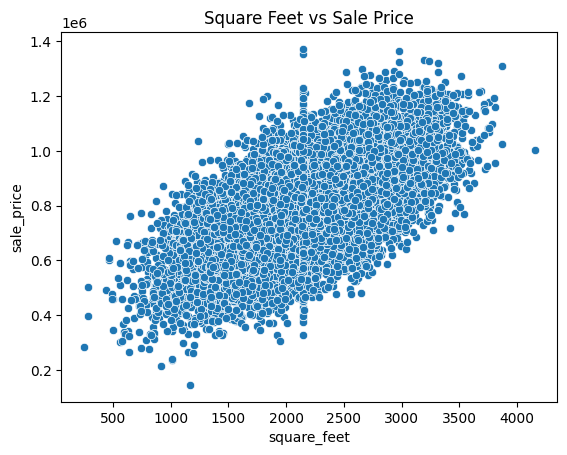

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="square_feet", y="sale_price", data=df)
plt.title("Square Feet vs Sale Price")

Text(0.5, 1.0, 'Lot Size vs Sale Price')

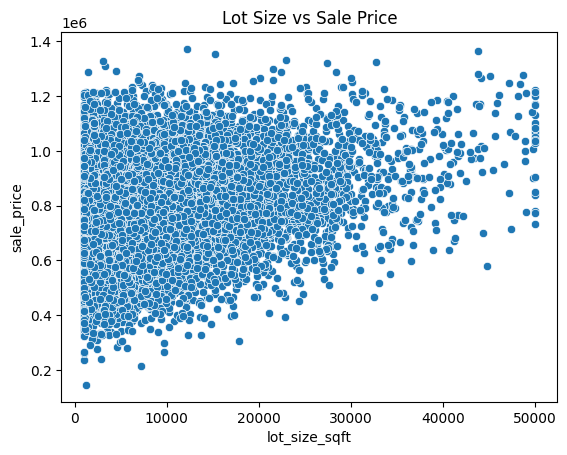

In [53]:
sns.scatterplot(x="lot_size_sqft", y="sale_price", data=df)
plt.title("Lot Size vs Sale Price")

Text(0.5, 1.0, 'Bedrooms vs Sale Price')

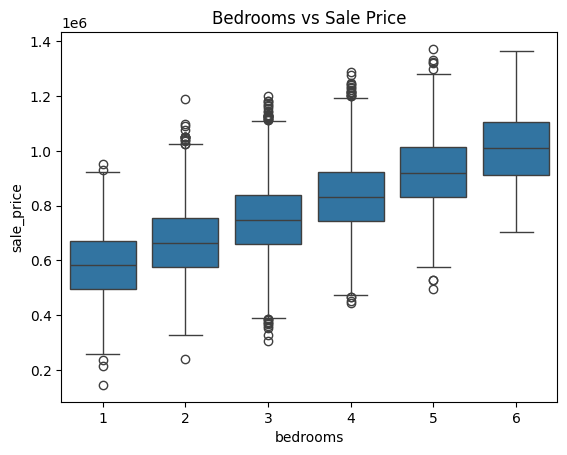

In [54]:
sns.boxplot(x="bedrooms", y="sale_price", data=df)
plt.title("Bedrooms vs Sale Price")

Text(0.5, 1.0, 'house_age to sale_price')

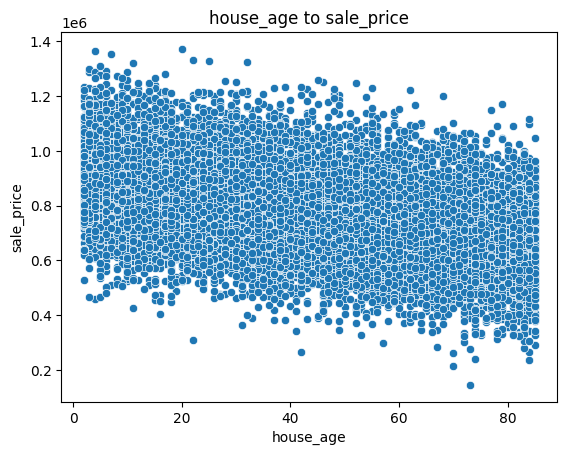

In [55]:
sns.scatterplot(x = "house_age",y = "sale_price",data = df)
plt.title("house_age to sale_price")

Text(0.5, 1.0, 'Years Since Renovation vs Price')

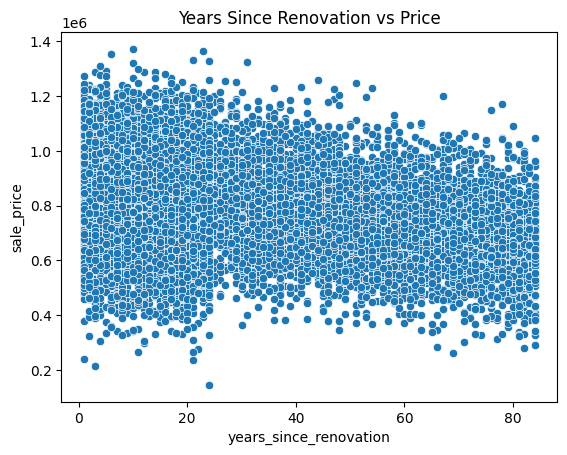

In [56]:
sns.scatterplot(x="years_since_renovation", y="sale_price", data=df)
plt.title("Years Since Renovation vs Price")

Text(0.5, 1.0, 'Total room vs Sale Price')

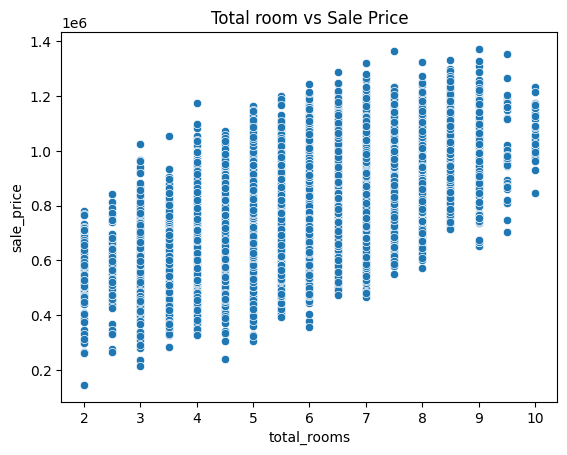

In [57]:
sns.scatterplot(x = "total_rooms", y = "sale_price", data = df)
plt.title("Total room vs Sale Price")

<Axes: >

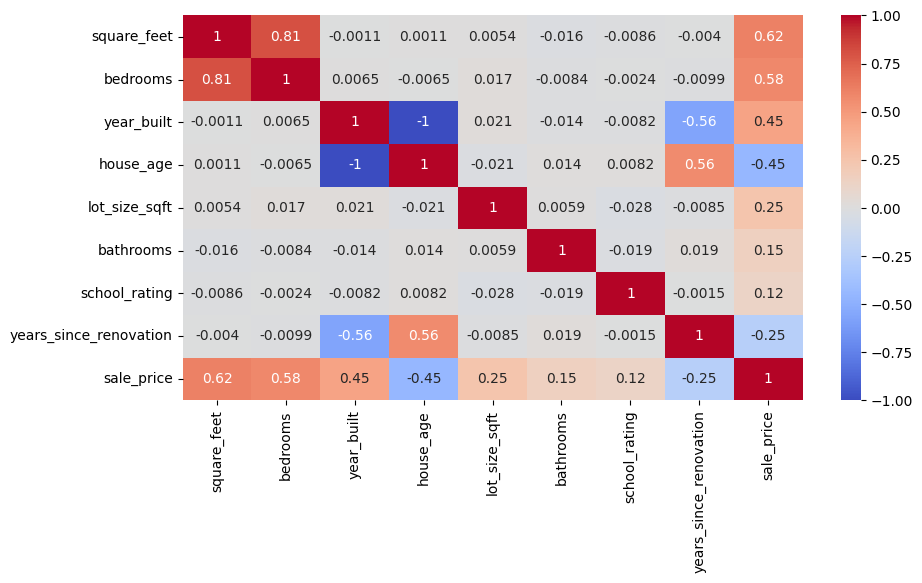

In [58]:
plt.figure(figsize=(10,5))
sns.heatmap(
    df[
        [
            "square_feet",
            "bedrooms",
            "year_built",
            "house_age",
            "lot_size_sqft",
            "bathrooms",
            "school_rating",
            "years_since_renovation",
            "sale_price"
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

SQUARE FEET INCREASE SALES PRICE


H₀ → Square feet does NOT affect sale price


H₁ → Square feet DOES affect sale price



In [59]:
from scipy import stats
 
r, p = stats.pearsonr(df["square_feet"], df["sale_price"])

print("Correlation:", r)
print("p-value:", p)
 
if p < 0.05:
    print("Reject H0 - square_feet is significant")
else:
    print("Fail to reject H0")

Correlation: 0.6150009379111868
p-value: 0.0
Reject H0 - square_feet is significant


AGE OF HOUSE AFFECTS PRICE

H0: Age category does not affect house price

H1: Age category affects house price


In [60]:
from scipy.stats import ttest_ind

moderate = df[df["age_category_moderate"] == 1]["sale_price"]
not_moderate = df[df["age_category_moderate"] == 0]["sale_price"]

t_stat_mod, p_mod = ttest_ind(moderate, not_moderate)

print("Moderate Category")
print("T-statistic:", t_stat_mod)
print("P-value:", p_mod)

if p_mod < 0.05:
    print("Reject H0 — Moderate age houses differ in price")
else:
    print("Fail to reject H0")
print("-" * 50)

old = df[df["age_category_old"] == 1]["sale_price"]
not_old = df[df["age_category_old"] == 0]["sale_price"]

t_stat_old, p_old = ttest_ind(old, not_old)

print("Old Category")
print("T-statistic:", t_stat_old)
print("P-value:", p_old)

if p_old < 0.05:
    print("Reject H0 — Old houses differ in price")
else:
    print("Fail to reject H0")
print("-" * 50)


very_old = df[df["age_category_very old"] == 1]["sale_price"]
not_very_old = df[df["age_category_very old"] == 0]["sale_price"]

t_stat_vo, p_vo = ttest_ind(very_old, not_very_old)

print("Very Old Category")
print("T-statistic:", t_stat_vo)
print("P-value:", p_vo)

if p_vo < 0.05:
    print("Reject H0 — Very old houses differ in price")
else:
    print("Fail to reject H0")
print("-" * 50)


print("Mean Prices by Category")
print("Moderate mean:", moderate.mean())
print("Old mean:", old.mean())
print("Very old mean:", very_old.mean())

Moderate Category
T-statistic: 26.78139281095474
P-value: 2.2171317063320533e-154
Reject H0 — Moderate age houses differ in price
--------------------------------------------------
Old Category
T-statistic: 4.663635365140552
P-value: 3.1335179064396e-06
Reject H0 — Old houses differ in price
--------------------------------------------------
Very Old Category
T-statistic: -49.929266005242596
P-value: 0.0
Reject H0 — Very old houses differ in price
--------------------------------------------------
Mean Prices by Category
Moderate mean: 855744.800217549
Old mean: 792211.1557248487
Very old mean: 706883.771829083


TOTAL ROOM INCREASES THE SALES PRICE

H₀:Total_rooms does not increase sale_price

H₁:Total_rooms increases sale_price

In [61]:
from scipy import stats

r, p = stats.pearsonr(df["total_rooms"], df["sale_price"])

print("Correlation:", r)
print("p-value:", p)

if p < 0.05:
    print("Reject H0 — Total_rooms increases price")
else:
    print("Fail to reject H0")

Correlation: 0.5691111253006714
p-value: 0.0
Reject H0 — Total_rooms increases price


RENOVATION INCREASES THE PRICE

H₀: Renovation does not increase price

H₁: Renovation increases price

In [62]:
renovated = df[df['was_renovated']==1]['sale_price']
not_renovated = df[df['was_renovated']==0]['sale_price']
t_stat, p_val = stats.ttest_ind(renovated, not_renovated)
print("T-test:", t_stat, "p-value:", p_val)

print("Renovated mean:", renovated.mean())
print("Not renovated mean:", not_renovated.mean())
if p_val < 0.05: 
    print("Reject H0 - Renovation increases price")
else:
    print("Fail to reject H0")

T-test: -0.8792155455653475 p-value: 0.37929850318517244
Renovated mean: 781392.5655119322
Not renovated mean: 783743.1131099353
Fail to reject H0


NEIGHBOURHOOD_TIER INCREASES THE PRICE

H₀: Neighbourhood_tier does not increase price

H₁: Neighbourhood_tier increases price

In [63]:
premium = df[df["neighborhood_tier_premium"] == 1]["sale_price"]
non_premium = df[df["neighborhood_tier_premium"] == 0]["sale_price"]
t_hood, p_hood = stats.ttest_ind(premium, non_premium)
 
print(f"T-statistic: {t_hood:.4f} | p-value: {p_hood:.4e}")
print(f"Mean (Premium): ${premium.mean():,.2f}")
print(f"Mean (Non-Premium): ${non_premium.mean():,.2f}")
 
if p_hood < 0.05:
    if premium.mean() > non_premium.mean():
        print("Decision: Reject H0 - Premium neighborhoods significantly increase house value.")
    else:
        print("Decision: Reject H0 - Neighborhood tier matters, but 'premium' houses are actually cheaper.")
else:
    print("Decision: Fail to reject H0 - Neighborhood tier does not have a significant effect on price.")

T-statistic: 29.3076 | p-value: 1.1938e-183
Mean (Premium): $873,922.12
Mean (Non-Premium): $767,092.61
Decision: Reject H0 - Premium neighborhoods significantly increase house value.


POOL INCREASES THE PRICE

H₀: Pool does not increase price

H₁: Pool increases price

In [64]:
pool = df[df["has_pool_yes"] == 1]["sale_price"]
no_pool = df[df["has_pool_yes"] == 0]["sale_price"]
t_pool, p_pool = stats.ttest_ind(pool, no_pool)
 
print(f"T-statistic: {t_pool:.4f} | p-value: {p_pool:.4e}")
print(f"Mean (Pool): ${pool.mean():,.2f}")
print(f"Mean (No Pool): ${no_pool.mean():,.2f}")
 
if p_pool < 0.05:
    if pool.mean() > no_pool.mean():
        print("Decision: Reject H0 - Houses with pools are significantly more expensive.")
    else:
        print("Decision: Reject H0 - Significant difference found, but pool houses cost less.")
else:
    print("Decision: Fail to reject H0 - Having a pool does not significantly impact price.")

T-statistic: 10.0163 | p-value: 1.5326e-23
Mean (Pool): $810,881.48
Mean (No Pool): $776,513.97
Decision: Reject H0 - Houses with pools are significantly more expensive.


FEATURE SELECTION

In [65]:
features = [
    "high_value_property_yes",
    "square_feet",
    "total_rooms",
    "year_built",
    "house_age",
    "lot_size_sqft",
    "neighborhood_tier_premium",
    "school_rating",
    "kitchen_quality_premium",
    "years_since_renovation",
    "has_pool_yes"

]

X = df[features]
y = df["sale_price"]

PREDICTING VALUE USING RANDOMFORESTREGRESSOR

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [67]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

# from sklearn.ensemble import GradientBoostingRegressor

# model = GradientBoostingRegressor()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [68]:
from sklearn.metrics import r2_score, mean_absolute_error

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

R2 Score: 0.8298531907606265
MAE: 53528.334503600694
